In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, chi2
from pathlib import Path
import numcosmo_sne.mcmc as mcmc
import numcosmo_sne.data as data
import numcosmo_sne.diagnostics as diagn
chainDir = Path("../outputs/chains/")
figDir = Path("../outputs/figs/")

# Single chain Union2.1 MCMC

In [27]:
names, z, mu, mu_err, p_low, Wmat = data.readUnionData(Path("../data/union2.1"))

In [28]:
lnProb = data.makeUnionLogPos(z, mu, Wmat)
Nwalk = 200000
seed = 12345
run = False

In [29]:
if run == True: # Run the 'seed' chain
    chain, accepted, logp = mcmc.metropolisHastings(lnProb, np.array([1.0, 0.0]), Nwalk, 0.01*np.eye(2), seed=seed)
    np.save(chainDir / f"{seed}_union_chain.npy", chain)
    np.save(chainDir / f"{seed}_union_accepted.npy", accepted)
    np.save(chainDir / f"{seed}_union_logp.npy", logp)
else: # Read an already saved 'seed' chain
    chain    = np.load(chainDir / f"{seed}_union_chain.npy")
    accepted = np.load(chainDir / f"{seed}_union_accepted.npy")
    logp     = np.load(chainDir / f"{seed}_union_logp.npy")

In [30]:
samples = chain[Nwalk//10:]
print(samples.shape)
print(diagn.acceptanceRate(accepted))
print(chain)

(180000, 2)
0.5018875094375472
[[1.         0.        ]
 [0.8576175  0.12637285]
 [0.77055132 0.10045552]
 ...
 [0.10218106 0.3541104 ]
 [0.089754   0.43581728]
 [0.089754   0.43581728]]


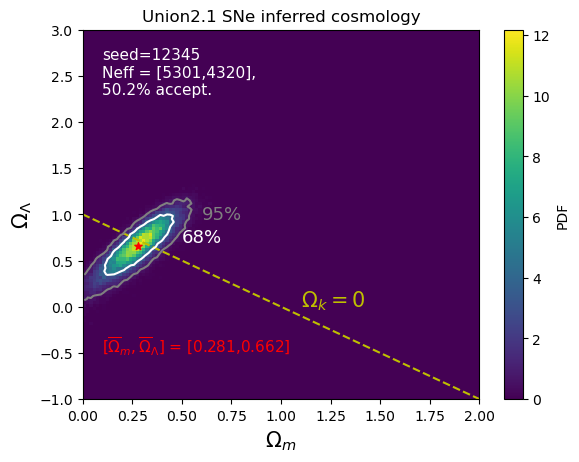

In [31]:
xsample = samples[:, 0]
ysample = samples[:, 1]
probs = [0.6827, 0.9545]
q68 = chi2.ppf(probs[0], df=2) # 1 sigma
q95 = chi2.ppf(probs[1], df=2) # 2 sigma

fig, ax = plt.subplots()
H, xedges, yedges, cmesh = ax.hist2d(xsample, ysample, bins=6*np.floor((0.9*Nwalk)**0.25).astype(int), range=[[0,2],[-1,3]], density=True)
plt.plot(np.linspace(0,2), 1-np.linspace(0,2), ls="--", c="y")

# Isocontours of MCMC samples ------------------------------------------------

# Probability mass in each bin
dx = np.diff(xedges)
dy = np.diff(yedges)
mass = H * dx[:, None] * dy[None, :]

density_flat = H.ravel()
mass_flat = mass.ravel()

# Sort from highest to lowest density
order = np.argsort(density_flat)[::-1]

mass_sorted = mass_flat[order]
cumprob = np.cumsum(mass_sorted)

# Field containing enclosed probability associated with each bin
prob_flat = np.empty_like(cumprob)
prob_flat[order] = cumprob

P = prob_flat.reshape(H.shape)

# Drawing the isocontours -----------------------------------------------------
xc = 0.5 * (xedges[:-1] + xedges[1:])
yc = 0.5 * (yedges[:-1] + yedges[1:])
Xc, Yc = np.meshgrid(xc, yc, indexing="xy")

cs = ax.contour(Xc, Yc, P.T, levels=probs, colors=["w", "gray"])
ax.text(0.5, 0.7, "68%", c="w", fontsize=13)
ax.text(0.6, 0.95, "95%", c="gray", fontsize=13)
ax.text(1.1, 0.0, r"$\Omega_k=0$", c="y", fontsize=15)

# Statistics -------------------------------------------------------------------
muMCMC = np.mean(samples, axis=0)
sigmaMCMC = np.std(samples, axis=0, ddof=1)
covMCMC = np.cov(samples.T)
acceptRate = diagn.acceptanceRate(accepted)
maxLag = min(len(xsample) // 10, 2000)
Neff = diagn.effectiveSampleSize(samples, maxLag)

ax.text(0.1, -0.5, r"[$\overline{\Omega}_m, \overline{\Omega}_\Lambda$] = "+f"[{muMCMC[0]:.3},{muMCMC[1]:.3}]", c="red", fontsize=11, horizontalalignment='left')
ax.text(0.1, 2.3, f"seed={seed}\nNeff = [{Neff[0]:.0f},{Neff[1]:.0f}],\n{100*acceptRate:.1f}% accept.", c="w", fontsize=11, horizontalalignment='left')
ax.scatter([muMCMC[0]], [muMCMC[1]], c="red", s=30, marker="*")

plt.xlabel(r"$\Omega_m$", fontsize=15)
plt.ylabel(r"$\Omega_\Lambda$", fontsize=15)
plt.title(r"Union2.1 SNe inferred cosmology")
plt.colorbar(cmesh, label="PDF")
plt.savefig(figDir / "unionMCMC.png", dpi=300)
plt.show()

# Multiple chain diagnostic

In [32]:
# Multiple chain diagnostic:
initPosList = [np.array([0.2, 0.5]), np.array([0.4, 0.9]), np.array([0.8, 0.4]), np.array([0.6, 1.2])]
seedList = [101, 202, 303, 404]
Nwalk = 30000
run = True

In [33]:
chains = []
for i in range(4):
    print(f"Chain number {i} ---")
    
    # To run the specified chains:
    if run == True:
        chain_i, accepted_i, logp_i = mcmc.metropolisHastings(lnProb, initPosList[i], Nwalk, 0.01*np.eye(2), seed=seedList[i])
        np.save(chainDir / f"{seedList[i]}_union_chain.npy", chain)
        np.save(chainDir / f"{seedList[i]}_union_accepted.npy", accepted)
        np.save(chainDir / f"{seedList[i]}_union_logp.npy", logp)
    else: # To read the specified chains:
        chain_i = np.load(chainDir / f"{seedList[i]}_union_chain.npy")

    chains.append(chain_i)

Chain number 0 ---
Chain number 1 ---
Chain number 2 ---
Chain number 3 ---


In [34]:
rHat = diagn.splitRhat(np.array(chains)[:,5000:,:])
print(rHat)

[1.00329776 1.00377832]


Output: [1.00329776 1.00377832]

Since rHat < 1.01, the multiple runs are consistent among eachother.